In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from collections import defaultdict

# added packages
import heapq
from matplotlib import colors



---
## Route-finding

Consider the map of the area to the west of the Engineering Center given below, with a fairly coarse Cartesian grid superimposed.

<img src="http://www.cs.colorado.edu/~tonyewong/home/resources/engineering_center_grid_zoom.png" style="width: 800px;"/>

The green square at $(x,y)=(1,15)$ is the starting location, and you would like to walk from there to the yellow square at $(25,9)$ with the **shortest total path length**. The filled-in blue squares are obstacles, and you cannot walk through those locations.  You also cannot walk outside of this grid.

Legal moves in the North/South/East/West directions have a step cost of 1. Moves in the diagonal direction (for example, from $(1,15)$ to $(2,14)$) are allowed, but they have a step cost of $\sqrt{2}$. 

Of course, you can probably do this problem (and likely have to some degree, in your head) without a search algorithm. But that will hopefully provide a useful "sanity check" for your answer.

#### Part A
Write a function `adjacent_states(state)`:
* takes a single argument `state`, which is a tuple representing a valid state in this state space
* returns in some form the states reachable from `state` and the step costs. How exactly you do this is up to you. One possible format for what this function returns is a dictionary with the keys being the tuple locations and the values of the keys being the step costs. E.g: adjacent_states((1,1)) =  $\{(2,1):1, (2,2):1.414\}$

Print to the screen the output for `adjacent_states((1,15))`.

In [2]:
# helper to construct a box in the environment
def builder(bottomLeftCorner, dimensions, env):
    for i in range(dimensions[0]):
        for j in range(dimensions[1]):
            env[i + bottomLeftCorner[0]][j + bottomLeftCorner[1]] = 1

# building environment
env = np.zeros((16,25), int) # array of zeros
builder((10,20), (6,5), env) # top right square
builder((8,9), (4,4), env) # middle squares
builder((10,11), (4,4), env) # middle squares
builder((0,4), (1,19), env) # bottom line
builder((1,0), (13,1), env) # base of pyramid
builder((2,1), (11,1), env) # layers of pyramid...
builder((3,2), (9,1), env)
builder((4,3), (7,1), env)

def adjacent_states(state):
    adjacents = []
    diagonal = 0
    for i in range(-1,2,1):
        for j in range(-1,2,1):
            diagonal += 1
            if state[0]+i <= 15 and state[0]+i >= 0 and state[1]+j <= 24 and state[1]+j >= 0:
                neighbor = (state[0]+i, state[1]+j)
                if env[neighbor[0]][neighbor[1]] != 1 and neighbor != state:
                    if diagonal % 2 == 1:
                        adjacents.append((neighbor, 1.414))
                    else:
                        adjacents.append((neighbor, 1))
    return adjacents

#### Part B
Three candidate heuristic functions might be:
1. `heuristic_cols(state, goal)` = number of columns between the argument `state` and the `goal`
1. `heuristic_rows(state, goal)` = number of rows between the argument `state` and the `goal`
1. `heuristic_eucl(state, goal)` = Euclidean distance between the argument `state` and the `goal`

Write a function `heuristic_max(state, goal)` that returns the maximum of all three of these heuristic functions for a given `state` and `goal`.

In [3]:
def hueristic_max(state, goal):
    def hueristic_cols(state, goal):
        return np.abs(goal[1] - state[1])
    def hueristic_rows(state, goal):
        return np.abs(goal[0] - state[0])
    def hueristic_euc(state, goal):
        return np.sqrt(np.square(goal[1] - state[1]) + np.square(goal[0] - state[0]))
    return round(max(hueristic_cols(state, goal), hueristic_rows(state, goal), hueristic_euc(state, goal)), 3)

#### Part C
Is the Manhattan distance an admissible heuristic function for this problem?  Explain why or why not.

The manhatten huersitic would not be admissible becuase it can overestimate the goal. This is becuase the agent in this problem can move diagnonally. "Stair stepping" will cost more than traveling diagnonally. Moving from (1,1) to (2,2) will cost 2 for the manhatten distance and cost 1.414 to travel diagnonally. 

#### Part D
Use A\* search and the `heuristic_max` heuristic to find the shortest path from the initial state at $(1,15)$ to the goal state at $(25,9)$. Your search **should not** build up the entire state space graph in memory. Instead, use the `adjacent_states` function from Part A.

In [4]:
# frontier will be in the form of a priority queue
class frontierPQ:
    # frontier will be a list containing tuples with a state, path to that state and a path cost
    def __init__(self, path = None):
        self.lst = [path]
        
    # adds path to frontier and then reorders from least cost to greatest
    def append(self, path):
        self.lst.append(path)
        sortedLst = sorted(self.lst, key=lambda x: x[2]) 
        self.lst = sortedLst
        
    # returns true if given path is in the frontier and false otherwise
    def contains(self, path):
        for s in self.lst:
            if s[0][0] == path: return True
        return False
    
    # returns first (least path cost) path and removes it from queue
    def pop(self):
        return self.lst.pop(0)
    
    # returns tuple containing data for desired state
    def getPath(self, state):
        for s in self.lst:
            if s[0] == state: return s
        

def astarSearch(start, goal, env, hueristic):
    # frontier object will contain a list of tuples with a state, path to that state and a path cost
    frontier = frontierPQ((start, [start], hueristic(start, goal)))
    # explored will be a list of explored states
    explored = []
    # while frontier not empty
    while frontier.lst: 
        path = frontier.pop()
        state = path[0]
        if state == goal: 
            return path[1]
        explored.append(state)
        # explores all neighbors of current state
        for neighbor in adjacent_states(state):
            # cost = cost of path without hueristic + cost to get to neighbor + hueristic of neighbor
            cost = round((path[2] - hueristic(state, goal)) + neighbor[1] + hueristic(neighbor[0], goal), 3)
            # if neighbor not in explored and not in frontier
            if (neighbor[0] not in explored) and (frontier.contains(neighbor[0]) == False):
                newPath = path[1].copy()
                newPath.append(neighbor[0])
                frontier.append((neighbor[0], newPath, cost))
            # if neighbor is in frontier and current path is less costly than original
            elif (frontier.contains(neighbor[0])) and (frontier.getPath(neighbor[0])[2] > cost):
                # replaces the more costly route with less costly route
                newPath = path[1].copy()
                newPath.append(neighbor[0])
                frontier.lst.remove(frontier.getPath(neighbor[0]))
                frontier.append((neighbor[0], newPath, cost))
    # if function exits while loop, no path was found            
    print("No path found")
    return

#### Part E
Make a figure depicting the optimal route from the initial state to the goal, similarly to how you depicted the maze solution in Homework 2.

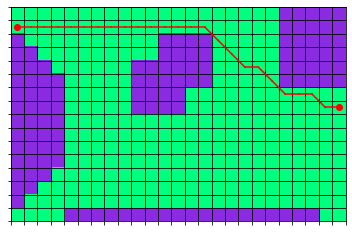

In [5]:
def plot_maze(env, path, start, goal):
    
    nrow, ncol = env.shape
    
    # create colormap
    cmap = colors.ListedColormap(['springgreen', 'blueviolet'])

    fig, ax = plt.subplots()
    ax.imshow(env, cmap=cmap, origin='lower')
    
    # draw gridlines
    ax.grid(which='major', axis='both', linestyle='-', color='k')
    ax.set_xticks(np.arange(-.5, ncol, 1))
    ax.set_yticks(np.arange(-.5, nrow, 1))
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    
    if path:
        for p in range(len(path)-1):
            point = path[p]
            nextpoint = path[p+1]
            plt.plot([point[1],nextpoint[1]], [point[0],nextpoint[0]], c='red')
        plt.scatter(start[1],start[0], color = 'red') # start
        plt.scatter(goal[1],goal[0], color = 'red') # end
    
    plt.show()
    
plot_maze(env, astarSearch((14,0), (8,24), env, hueristic_max), (14,0), (8,24))